In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

SCALING_WEIGHTS = [100/15, 100/8, 100/100]

In [2]:
data = pd.read_pickle("ml_data_onsite_start.pickle")
for key in data.keys():
    print(key)

X
y


In [3]:
for key in data["X"].keys():
    print(key)

train
val
live_test


In [4]:
for key in data["y"].keys():
    print(key)

train
val


In [5]:
X_train = data["X"]["train"]
y_train = data["y"]["train"]

X_val = data["X"]["val"]
y_val = data["y"]["val"]

X_test = data["X"]["live_test"]

In [6]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape

((2024, 5, 5, 5, 6), (2024, 3), (376, 5, 5, 5, 6), (376, 3), (200, 5, 5, 5, 6))

In [7]:
def vis(arr):
    plt.figure(figsize=(8, 8))

    cnt = 1
    for z in range(5):
        for q in range(6):
            plt.subplot(5, 6, cnt)
            plt.imshow(arr[:, :, z, q], vmin=-40, vmax=40, cmap='hsv')
            plt.grid()
            plt.axis('off')
            cnt += 1

    plt.tight_layout()

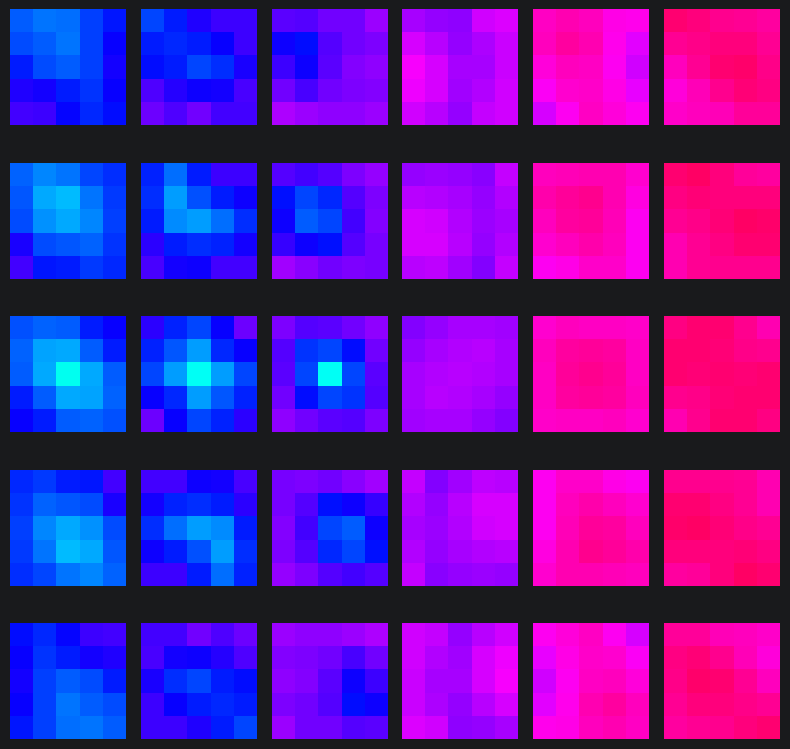

In [8]:
vis(X_train[0])

In [24]:
print(X_train.shape)
print(y_train.shape)

print("Min:", X_train.min())
print("Max:", X_train.max())
print("Mean:", X_train.mean())
print("Std:", X_train.std())

print("Targets:")
print(pd.DataFrame(y_train).describe())

(2024, 5, 5, 5, 6)
(2024, 3)
Min: -14.4009822477
Max: 101.0012400287
Mean: 28.637439957560943
Std: 17.28319174083578
Targets:
                 0            1            2
count  2024.000000  2024.000000  2024.000000
mean     -1.035139     1.460841    11.546200
std       3.507827     5.941608    14.155502
min     -20.736600   -31.017100    -0.106002
25%      -1.699156    -1.465189     4.450752
50%      -0.111445     0.828237     6.684437
75%       0.529047     4.349978    11.084964
max       7.222572    18.540382   231.245026


In [42]:
cube = X_train[0]

faces = {
    "left":   cube[0, :, :, :],
    "right":  cube[-1, :, :, :],

    "front":  cube[:, 0, :, :],
    "back":   cube[:, -1, :, :],

    "top":    cube[:, :, 0, :],
    "bottom": cube[:, :, -1, :],
}

pairs = [
    ("left", "right"),
    ("front", "back"),
    ("top", "bottom"),
]

for name1, name2 in pairs:
    a = faces[name1].ravel()
    b = faces[name2].ravel()

    mae = np.mean(np.abs(a - b))
    corr = np.corrcoef(a, b)[0, 1]

    print(f"{name1} vs {name2}")
    print(f"  MAE: {mae:.4f}")
    print(f"  Correlation: {corr:.4f}")

left vs right
  MAE: 2.3603
  Correlation: 0.9096
front vs back
  MAE: 2.4244
  Correlation: 0.9241
top vs bottom
  MAE: 2.5880
  Correlation: 0.9167


In [43]:
pairs = [
    ("left", "right"),
    ("front", "back"),
    ("top", "bottom"),
]

for name1, name2 in pairs:
    a = faces[name1].ravel()
    b = faces[name2].ravel()

    mae = np.mean(np.abs(a - b))
    corr = np.corrcoef(a, b)[0, 1]

    print(f"{name1} vs {name2}")
    print(f"  MAE: {mae:.4f}")
    print(f"  Correlation: {corr:.4f}")

left vs right
  MAE: 2.3603
  Correlation: 0.9096
front vs back
  MAE: 2.4244
  Correlation: 0.9241
top vs bottom
  MAE: 2.5880
  Correlation: 0.9167


In [44]:
cube = X_train[0]

left = cube[0, :, :, :]
right = cube[-1, :, :, :]

for channel in range(6):
    a = left[:, :, channel].ravel()
    b = right[:, :, channel].ravel()

    corr = np.corrcoef(a, b)[0, 1]
    mae = np.mean(np.abs(a - b))

    print(
        f"Channel {channel}: "
        f"Correlation = {corr:.4f}, "
        f"MAE = {mae:.4f}"
    )

Channel 0: Correlation = -0.6551, MAE = 4.3143
Channel 1: Correlation = 0.0226, MAE = 3.3030
Channel 2: Correlation = -0.3189, MAE = 2.0374
Channel 3: Correlation = 0.5757, MAE = 1.0444
Channel 4: Correlation = -0.1300, MAE = 1.6282
Channel 5: Correlation = -0.4524, MAE = 1.8344


In [45]:
correlations = []

for cube in X_train:
    left = cube[0, :, :, :]
    right = cube[-1, :, :, :]

    channel_corrs = []

    for channel in range(6):
        a = left[:, :, channel].ravel()
        b = right[:, :, channel].ravel()

        corr = np.corrcoef(a, b)[0, 1]
        channel_corrs.append(corr)

    correlations.append(channel_corrs)

correlations = np.array(correlations)

for channel in range(6):
    print(
        f"Channel {channel}: "
        f"Median correlation = "
        f"{np.nanmedian(correlations[:, channel]):.4f}"
    )

Channel 0: Median correlation = 0.0427
Channel 1: Median correlation = -0.0284
Channel 2: Median correlation = -0.1476
Channel 3: Median correlation = -0.0630
Channel 4: Median correlation = -0.0276
Channel 5: Median correlation = -0.1466


In [9]:
# Result evaluation / writing predictions

def test_solution(X_train, y_train, X_val, y_val, feature_num=0):
    assert X_train.shape[-1] <= 300, "Too many features! Should be less than 300"
    assert X_val.shape[-1] <= 300, "Too many features! Should be less than 300"

    model =  LinearRegression().fit(
        X_train,
        y_train[:, feature_num]
    )
    predictions = model.predict(X_val)
    rmse = mean_squared_error(
        predictions,
        y_val[:, feature_num]
    )**.5
    normalized_rmse = rmse * SCALING_WEIGHTS[feature_num]
    print(f"Property #{feature_num}:    raw RMSE={rmse:.6f}")
    print(f"Property #{feature_num}: scaled RMSE={normalized_rmse:.6f}")
    return round(normalized_rmse, 6)

In [39]:
# features compression

def extract_features(X):
    means = (X**3).mean(axis=(1, 2, 3))
    stds = X.std(axis=(1, 2, 3))
    maxs = X.max(axis=(1, 2, 3))
    mins = X.min(axis=(1, 2, 3))

    return np.concatenate(
        [means, stds, maxs, mins],
        axis=1
    )

In [40]:
%%time
total_score = 0
for feature_number in range(3):
  total_score += test_solution(
      extract_features(X_train),
      y_train,
      extract_features(X_val),
      y_val,
      feature_num=feature_number
  )
  print()
total_score /= 3
print('='*16)
print(f"Total score = {total_score:.6f}")

Property #0:    raw RMSE=0.569923
Property #0: scaled RMSE=3.799487

Property #1:    raw RMSE=0.100019
Property #1: scaled RMSE=1.250237

Property #2:    raw RMSE=1.121229
Property #2: scaled RMSE=1.121229

Total score = 2.056984
CPU times: user 654 ms, sys: 951 μs, total: 655 ms
Wall time: 154 ms


In [46]:
def dummy_feature_extractor(X):
    X_new = X.reshape((X.shape[0], -1)) # ravel
    X_new = X_new[:, :300] # pick first 300 features
    return X_new

dummy_feature_extractor(X_train).shape

(2024, 18)

In [51]:
%%time
total_score = 0
for feature_number in range(3):
  total_score += test_solution(
      dummy_feature_extractor(X_train),
      y_train,
      dummy_feature_extractor(X_val),
      y_val,
      feature_num=feature_number
  )
  print()
total_score /= 3
print('='*16)
print(f"Total score = {total_score:.6f}")


Property #0:    raw RMSE=1.006342
Property #0: scaled RMSE=6.708946

Property #1:    raw RMSE=0.773304
Property #1: scaled RMSE=9.666301

Property #2:    raw RMSE=1.617753
Property #2: scaled RMSE=1.617753

Total score = 5.997667
CPU times: user 231 ms, sys: 47 μs, total: 231 ms
Wall time: 64 ms


In [19]:
# Prepare Answers

def generate_predictions(X_train, y_train, X_test, feature_num=0):
    assert X_train.shape[-1] <= 300
    assert X_test.shape[-1] <= 300

    model = LinearRegression().fit(
        X_train,
        y_train[:, feature_num]
    )
    predictions = model.predict(X_test)
    return predictions


## Generate solutions and write to the file
combined = {'ID': np.arange(X_test.shape[0])}

for feature_number in range(3):
    predictions = generate_predictions(
        dummy_feature_extractor(X_train),
        y_train,
        dummy_feature_extractor(X_test),
        feature_num=feature_number
    )

    combined[f'y{feature_number+1}'] = predictions

pd.DataFrame(combined).to_csv('predictions.csv', index=False)

In [24]:
# load the test dataset
loaded = pd.read_pickle("./Solution/test_set/ml_data_onsite_final_test.pickle")
X_test_final = loaded['X']['final_test']


# make final predictions
combined = {'ID': np.arange(X_test_final.shape[0])}

for feature_number in range(3):
    predictions = generate_predictions(
        dummy_feature_extractor(X_train),
        y_train,
        dummy_feature_extractor(X_test_final),
        feature_num=feature_number
    )

    combined[f'y{feature_number+1}'] = predictions

pd.DataFrame(combined).to_csv('final_predictions.csv', index=False)